In [1]:
# Multivariate data exploration.
# Intent of this file is to analyze data from the National Survey of College Graduates (NSCG) using data regarding 2017 graudates.
# Focus on mechanical engineers.

# Setup:
import math
import collections

import numpy
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import datetime
from matplotlib import style
#importing seaborn for nice boxplots
import seaborn as sns


In [2]:
# Import the 'ME_salaries.csv' file from the data directory

me_sal = pd.read_csv('../../data/ME_salaries.csv', names=['Salary', 'Age', 'Gender'], skiprows=1)
print(me_sal.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Salary  3616 non-null   int64 
 1   Age     3616 non-null   int64 
 2   Gender  3616 non-null   object
dtypes: int64(2), object(1)
memory usage: 84.9+ KB
None


In [3]:
# Looking at respondents who didn't list their salary, pd.isnull isn't working to find empty arrays of "" recorded for salary.
# However there are 15 respondents who answered having 0 for their salary:
me_no_sal = me_sal.loc[me_sal['Salary'] == 0]

# Therefore it would make sense to remove these responses at outliers, there could be many reasons why someone would list their salary at 0.
me_sal = me_sal.loc[me_sal['Salary'] != 0]
# Need to reset the index after removing some rows:
me_sal.reset_index(drop=True, inplace=True)

In [4]:
# Taking a look at the genders shown in the dataframe:
print(me_sal.Gender.value_counts())

# It appears that 3228 men and 373 women responded with no other possible gender identities being listed.


Gender
M    3228
F     373
Name: count, dtype: int64


0       32
1       31
2       38
3       36
4       60
        ..
3596    32
3597    28
3598    56
3599    58
3600    40
Name: Age, Length: 3601, dtype: int64
Age
75      5
73      5
71      7
23      8
74     11
72     12
70     13
66     19
67     20
68     20
69     22
64     22
65     23
61     32
62     34
63     34
24     38
60     42
41     54
39     55
50     59
58     61
51     62
44     63
48     64
40     64
49     64
59     66
47     69
46     70
54     70
56     71
25     72
43     72
52     73
57     74
38     75
45     76
42     77
37     82
55     87
35     87
53     87
36     88
26    103
34    125
27    137
33    139
28    143
32    165
31    185
29    194
30    201
Name: count, dtype: int64
53


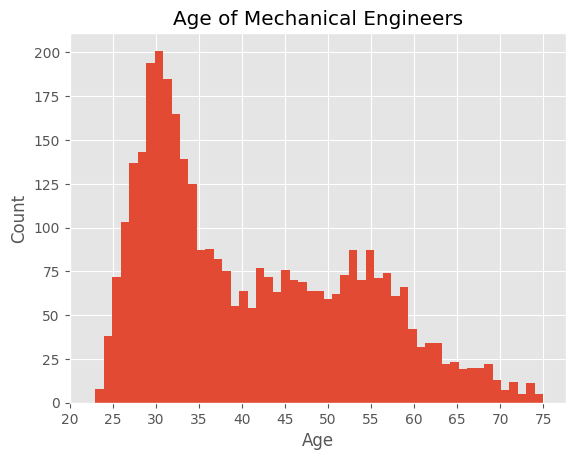

In [5]:
# With the data imported, plots could provide more insight into each category.
# print(me_sal.Age.value_counts())

# ages = me_sal.sort_values('Age')
age_count = me_sal['Age']

# age_count = age_count.sort_values(ascending=True)
print(age_count)
print(age_count.value_counts().sort_values(ascending=True))
# How many bins should be in the histogram should be equal to the number of unique ages recorded
print(len(me_sal.Age.unique()))
# Plotting the age of mechanical engineers that responded in a histogram.
style.use('ggplot')
plt.hist(me_sal['Age'],
         bins=len(me_sal.Age.unique()))
plt.title('Age of Mechanical Engineers')
plt.xlabel('Age')
plt.xticks(np.linspace(20, 75, 12))
plt.ylabel('Count')
plt.show()

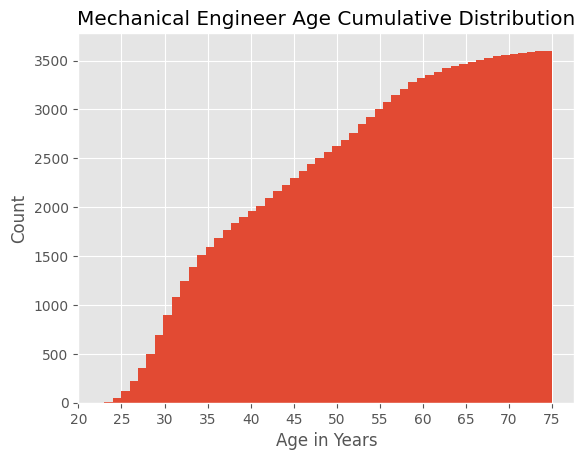

In [6]:
# A cumulative distribution plot would also be nice:
plt.hist(me_sal['Age'],
         bins=len(me_sal.Age.unique()),
         cumulative=True)
plt.title('Mechanical Engineer Age Cumulative Distribution' )
plt.xlabel('Age in Years')
plt.xticks(np.linspace(20, 75, 12))
plt.ylabel('Count')
plt.show()

Gender
M    3228
F     373
Name: count, dtype: int64


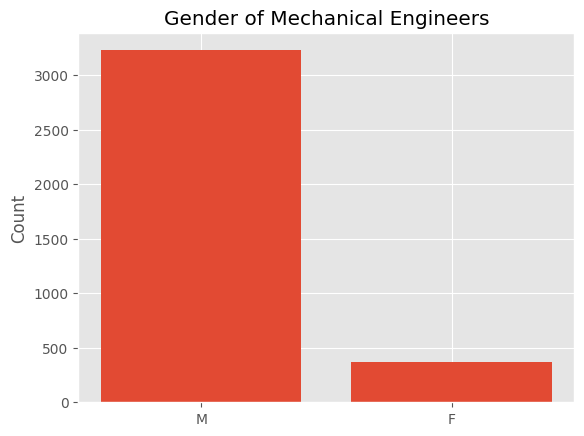

In [7]:
# Exploring Gender of mechanical engineers, a barchart would help compare how many of each there are:

me_gender = me_sal.Gender.unique()
me_genderCt = me_sal.Gender.value_counts()
print(me_genderCt)

plt.bar(me_gender,me_genderCt)
plt.title('Gender of Mechanical Engineers')
plt.ylabel('Count')
plt.yticks(numpy.arange(0, 3500, 500))
plt.show()

      Salary  Age Gender
3     130000   36      F
17     80228   37      F
19    112000   33      F
25     62000   37      F
38     24000   47      F
...      ...  ...    ...
3557   83500   32      F
3558   75000   29      F
3560     140   29      F
3564   31200   54      F
3596  107200   32      F

[373 rows x 3 columns]


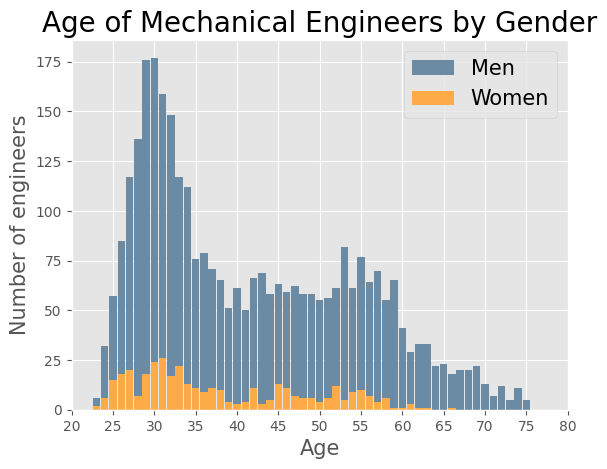

In [11]:
#Perhaps an age histogram that compares gender would also be interesting:

# Separating both men and women responses:
me_men = me_sal.loc[me_sal['Gender'] == 'M']
me_women = me_sal.loc[me_sal['Gender'] == 'F']

# A unique challenge here, there are some ages that have no women in that bin, therefore stacking the bins with two plots has the bins offset from one another.

print(me_women)
# Simple solution, just make the range of the bins available, and make the steps be by 1 for intergers.
plt.hist(me_men['Age'],
         bins=range(0,100,1),
         color='xkcd:grey blue',
         rwidth=0.9,
         stacked=True,
         align='left')
plt.hist(me_women['Age'],
         bins=range(0,100,1),
         color='xkcd:light orange',
         rwidth=0.9,
         stacked=True,
         align='left')
plt.title('Age of Mechanical Engineers by Gender', fontsize=20)
plt.legend(labels=['Men', 'Women'], fontsize= 15)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Number of engineers', fontsize=15)
plt.xlim(20,80)
plt.xticks(list(range(20,85,5)))
plt.show()

# hard to tell if there is a correlation between age and gender, another plot may be required, but the information is interesting regardless.

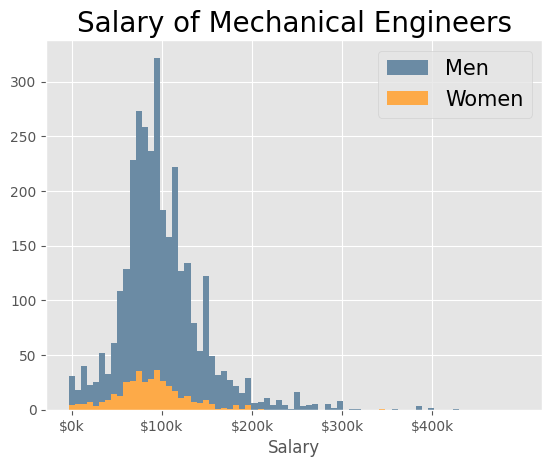

In [12]:
#Comparing salary versus gender instead:
salary_ticks= list(range(0,500,100))
plt.hist(me_men['Salary'],
         bins=np.linspace(0, 500000, 75),
         color='xkcd:grey blue',
         stacked=True,
         align='left')
plt.hist(me_women['Salary'],
         bins=np.linspace(0,500000,75),
         color='xkcd:light orange',
         stacked=True,
         align='left')
plt.title('Salary of Mechanical Engineers', fontsize=20)
plt.xlabel('Salary')
plt.xticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks])
plt.legend(labels=['Men', 'Women'], fontsize=15)
plt.show()

C:\Users\Brad\AppData\Local\Temp\ipykernel_10236\4176358549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=me_sal, x='Salary', y= 'Gender',


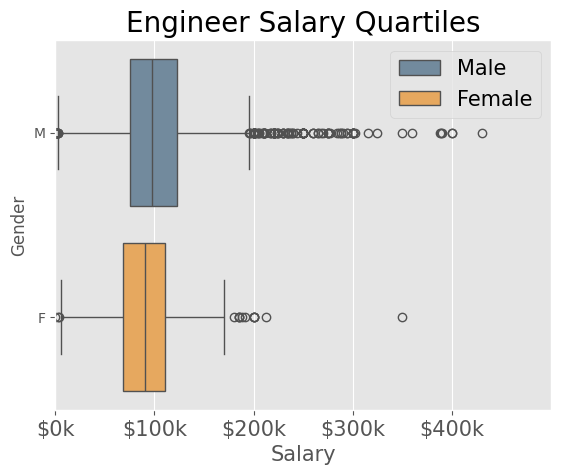

In [14]:
#Again hard to tell the difference at a glance with the population differences.

# A side by side boxplot will give information regarding quartiles and the median, possibly giving insights.
# seaborn makes a asethicically nice box plot, which can convey infomation easliy.
# plt.style.use('bmh')
sns.boxplot(data=me_sal, x='Salary', y= 'Gender',
            palette=[sns.xkcd_rgb['grey blue'], sns.xkcd_rgb['light orange']])
plt.title('Engineer Salary Quartiles', fontsize=20)
plt.xlabel('Salary', fontsize=15)
plt.xticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks], fontsize=15)
plt.xlim(0,500000)
plt.legend(['Male', 'Female'], fontsize=15)

plt.show()
# while not perfect, its a start. Would like to make the fontsize larger for the y axis.


C:\Users\Brad\AppData\Local\Temp\ipykernel_10236\1215831997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=me_sal, x='Age', y='Gender',


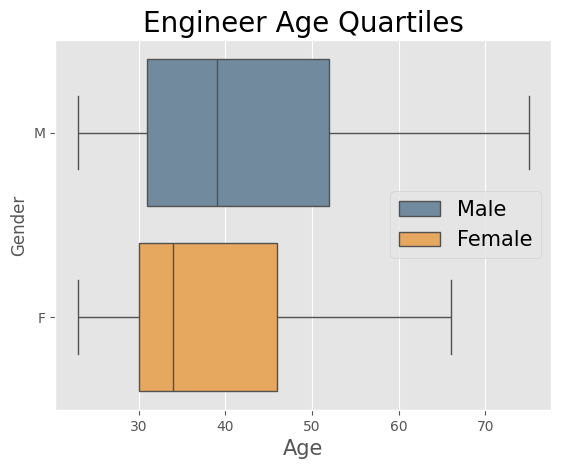

In [15]:
# Boxplot for age of mechanical engineers with gender in mind:
sns.boxplot(data=me_sal, x='Age', y='Gender',
            palette=[sns.xkcd_rgb['grey blue'], sns.xkcd_rgb['light orange']])
plt.title('Engineer Age Quartiles', fontsize=20)
plt.xlabel('Age', fontsize=15)
plt.legend(['Male','Female'],fontsize=15)
plt.show()


In [ ]:
# looking at both boxplots, they would imply that female engineers as a median have slighly lower salaries than their male counterparts.
# It also appears that a larger porportion of women engineers are younger.


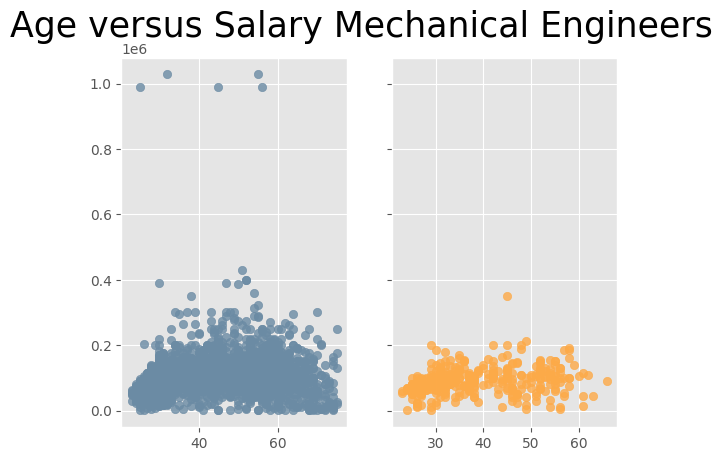

In [17]:
#a scatterplot showing the age(x-axis) vs Salary may show trends between the two, where we would expect older engineers to be paid more.
# Having 1 plot containing both the data for men and women superimposed on one another is difficult to read, so two subplots seems to be a better option.

fig, ax = plt.subplots(1, 2, sharey=True)
ax[0].scatter(me_men['Age'], me_men['Salary'],
            c='xkcd:grey blue',
            alpha= 0.8)
ax[1].scatter(me_women['Age'], me_women['Salary'],
            c='xkcd:light orange',
            alpha= 0.8)
ax[0]
fig.suptitle('Age versus Salary Mechanical Engineers', fontsize=25)
plt.show()